# CSI 1000 / IM American Carry-Put Demo

**Valuation date and calibration window:** configured in the first code cell below. The sample size includes the valuation date.  
**Scope:** the carry-put optional component only; the linear IM futures leg is deliberately excluded.

The notebook recalibrates the independent two-factor OU carry model with a configurable observation-noise equation and an $\eta_{fast}$ cap of 6, estimates CSI 1000 historical volatility over the same dates, derives the locked carry from the selected observed futures quote, performs deterministic daily backward induction, and profiles fixed $\eta_{fast}$ values with conditional re-optimization.

## Model and conventions

The carry state is

$$c_t=\theta+x_{s,t}+x_{f,t}, \qquad dx_{j,t}=-\kappa_jx_{j,t}dt+\eta_jdW_t^j,$$

with independent slow and fast shocks and $0<\kappa_s<\kappa_f$. Carry maturity and observation gaps use trading sessions divided by 244. Futures **close** and CSI 1000 spot close are used, with continuously compounded $r=0.014$.

The historical calibration is provisionally interpreted under the pricing measure. This is a prototype assumption, not a production risk-neutral calibration.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, Markdown, display

DEMO_ROOT = Path.cwd().resolve()
if DEMO_ROOT.name.lower() != 'demo':
    DEMO_ROOT = DEMO_ROOT / 'Demo'
sys.path.insert(0, str(DEMO_ROOT))

# Reload Demo-local code so rerunning this cell picks up file changes made
# after the current Jupyter kernel was started.
for module_name in [
    'demo_workflow', 'profile_analysis', 'option_pricing',
    'calibration', 'demo_quality', 'calendar_utils',
]:
    sys.modules.pop(module_name, None)

from demo_workflow import run_demo  # noqa: E402

# User inputs: SAMPLE_SIZE counts usable trading dates including VALUATION_DATE.
VALUATION_DATE = '2026-08-10'
SAMPLE_SIZE = 488
FUTURES_CONTRACT = 'IM2609'
HEDGE_FUTURES_CONTRACTS = ('IM2609', 'IM2703')
OBSERVATION_NOISE_MODEL = 'constant_log_futures'  # 'constant_log_futures' or 'constant_carry'
KAPPA_GAP_UPPER_BOUND = 90.0
ETA_FAST_UPPER_BOUND = 6.0
OUTPUT_DIR = DEMO_ROOT / (
    'outputs_log_futures' if OBSERVATION_NOISE_MODEL == 'constant_log_futures' else 'outputs'
)

# This performs the 12-start calibration, fixed-eta profile, option pricing, and export.
demo = run_demo(
    valuation_date=VALUATION_DATE,
    sample_size=SAMPLE_SIZE,
    futures_contract=FUTURES_CONTRACT,
    hedge_futures_contracts=HEDGE_FUTURES_CONTRACTS,
    observation_noise_model=OBSERVATION_NOISE_MODEL,
    kappa_gap_upper_bound=KAPPA_GAP_UPPER_BOUND,
    eta_fast_upper_bound=ETA_FAST_UPPER_BOUND,
    output_dir=OUTPUT_DIR,
)
print('Demo completed; outputs:', OUTPUT_DIR)

Demo completed; outputs: D:\Jupyter_files\Carry_curve_calibration\Demo\outputs_log_futures


## 1. Configured calibration sample

In [2]:
sample_keys = [
    'sample_start', 'sample_end', 'curve_dates', 'accepted_observations',
    'excluded_observations_within_window', 'distinct_contracts',
    'return_observations', 'historical_volatility',
    'observation_noise_model', 'observation_noise_parameter',
    'observation_noise_parameter_value'
]
pd.DataFrame({
    'quantity': sample_keys,
    'value': [demo.calibration.metrics[key] for key in sample_keys],
})

,quantity,value
0,sample_start,2024-08-05
1,sample_end,2026-08-10
2,curve_dates,488
3,accepted_observations,1807
4,excluded_observations_within_window,145
5,distinct_contracts,28
6,return_observations,487
7,historical_volatility,0.277109
8,observation_noise_model,constant_log_futures
9,observation_noise_parameter,sigma_log_futures


The window is selected by **distinct accepted curve date**, not by individual contract row. The 244 closing levels provide 243 close-to-close log returns for historical volatility.

## 2. Two-factor OU maximum-likelihood calibration

In [3]:
parameter_columns = [
    'parameter', 'estimate', 'standard_error',
    'slow_half_life_sessions', 'fast_half_life_sessions'
]
display(demo.calibration.parameter_table[parameter_columns])
pd.DataFrame({
    'diagnostic': ['log likelihood', 'AIC', 'BIC', 'carry RMSE (bp)',
                   'futures RMSE (points)', 'optimizer converged', 'stable Hessian',
                   'eta-fast upper bound', 'eta-fast at bound', 'kappa gap at bound'],
    'value': [demo.calibration.metrics[key] for key in [
        'log_likelihood', 'aic', 'bic', 'carry_rmse_bps',
        'futures_rmse_points', 'optimizer_converged', 'hessian_stable',
        'eta_fast_upper_bound', 'eta_fast_at_upper_bound',
        'kappa_fast_minus_slow_at_upper_bound'
    ]],
})

,parameter,estimate,standard_error,slow_half_life_sessions,fast_half_life_sessions
0,kappa_slow,0.798560,0.112123,211.791091,8.608467
1,kappa_fast,19.646693,0.931431,211.791091,8.608467
2,theta,0.093181,0.004134,211.791091,8.608467
3,eta_slow,0.058109,0.003787,211.791091,8.608467
4,eta_fast,1.366777,0.071531,211.791091,8.608467
5,sigma_log_futures,0.001014,0.000022,211.791091,8.608467


,diagnostic,value
0,log likelihood,5720.267011
1,AIC,-11428.534021
2,BIC,-11395.537482
3,carry RMSE (bp),124.064845
4,futures RMSE (points),5.367132
5,optimizer converged,True
6,stable Hessian,True
7,eta-fast upper bound,6.0
8,eta-fast at bound,False
9,kappa gap at bound,False


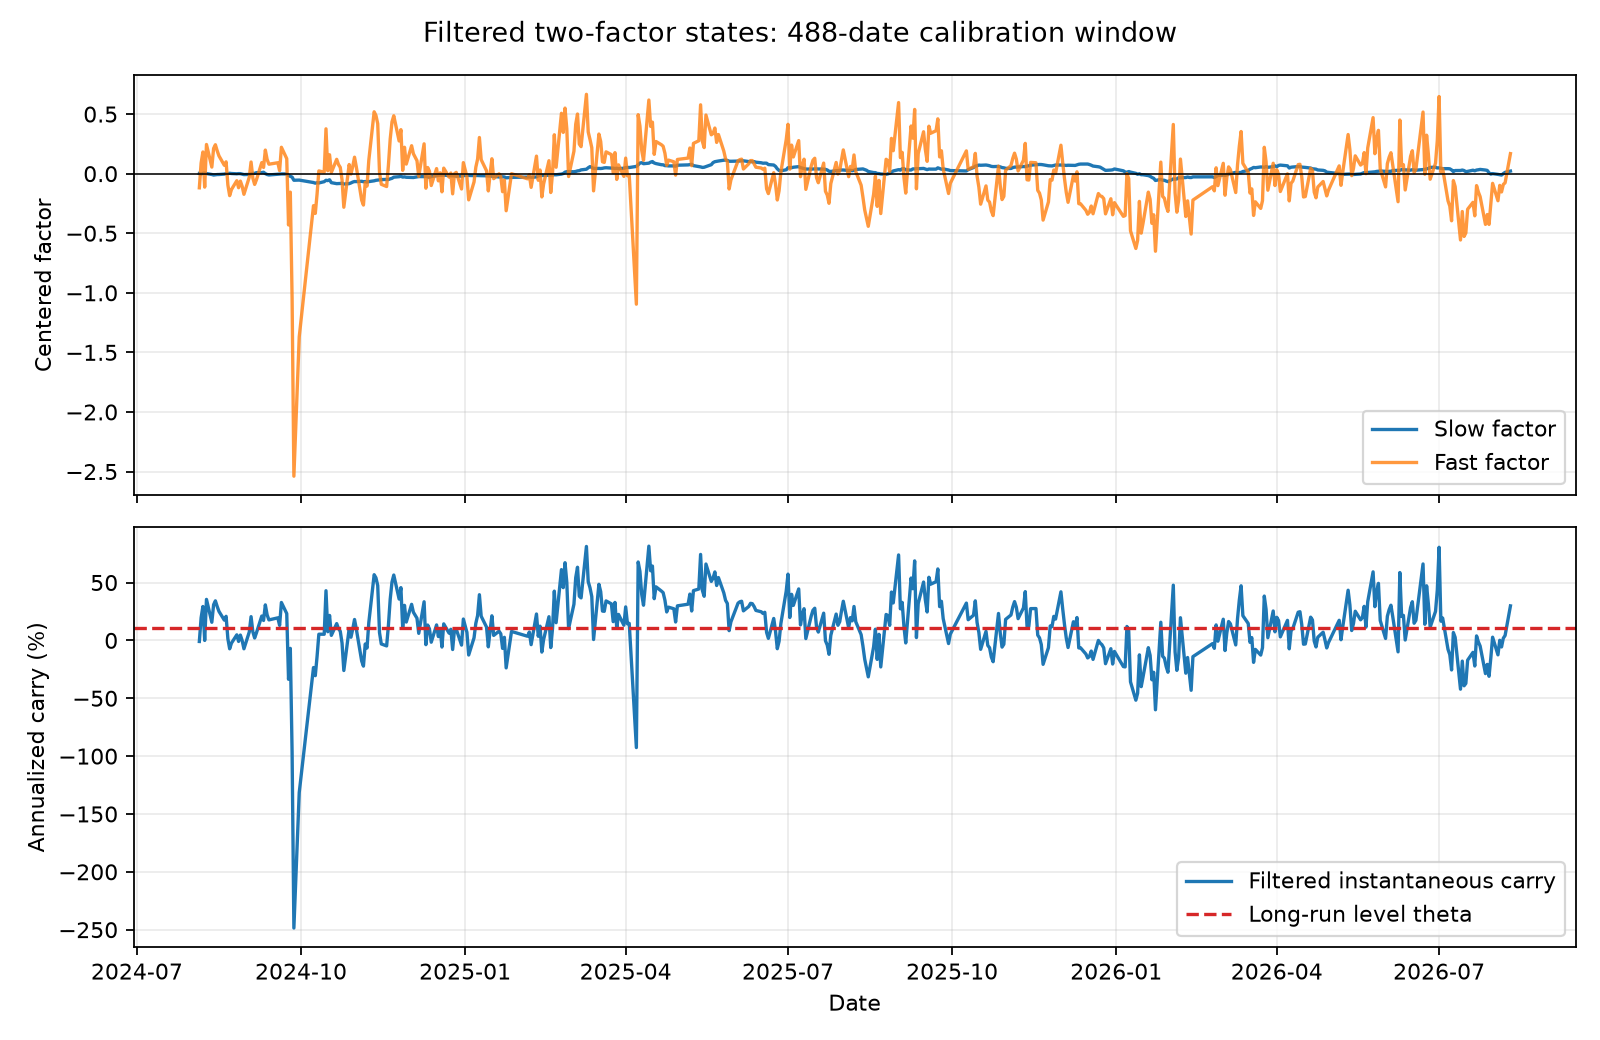

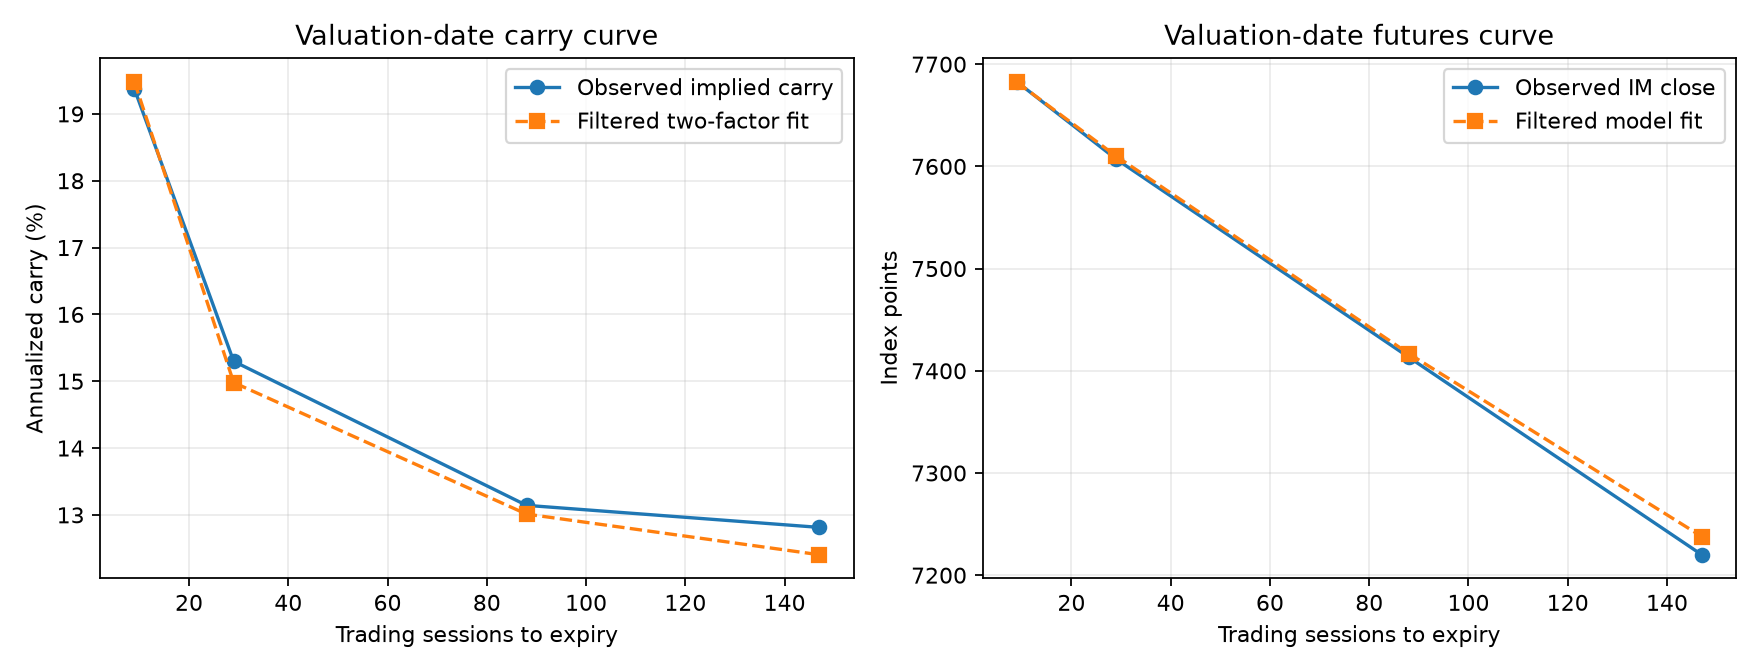

In [4]:
display(Image(filename=str(DEMO_ROOT / 'outputs' / 'charts' / 'filtered_states.png')))
display(Image(filename=str(DEMO_ROOT / 'outputs' / 'charts' / 'latest_curve.png')))

The revised $\eta_{fast}$ cap is 6. An interior estimate resolves the original volatility-bound problem. The demo separately checks the $\kappa_{fast}-\kappa_{slow}$ bound because relaxing one constraint can expose pressure on another.

## 3. Selected-contract locked carry and historical spot volatility

The contractual carry strike is derived from the observed inception quote:

$$q_{0,T}=r-\frac{\log(F_{0,T}/S_0)}{T}, \qquad T=\frac{N_{sessions}}{244}.$$

In [5]:
contract = demo.summary['contract']
display(pd.DataFrame({
    'input': list(contract),
    'value': list(contract.values()),
}))
# display(pd.DataFrame([demo.summary['calendar']['im2703_diagnostic']]).T.rename(columns={0: 'IM2703 calendar status'}))

,input,value
0,valuation_date,2026-08-10
1,contract,IM2609
2,expiry,2026-09-18
3,sessions_to_expiry,29
4,initial_spot,7733.9
5,initial_futures,7607.2
6,risk_free_rate,0.014
7,historical_spot_volatility,0.277109
8,locked_carry,0.15298


## 4. Option-only payoff and pricing

At an exercise date $t$, the complete product can be decomposed as

$$\max\{S_te^{(r-q_{0,T})(T-t)},F_{t,T}\}-F_{0,T} = (F_{t,T}-F_{0,T}) + \left[S_te^{(r-q_{0,T})(T-t)}-F_{t,T}\right]^+.$$

This demo deliberately omits the first, linear futures term. It prices only

$$G_t=S_t\left[e^{(r-q_{0,T})(T-t)}-\frac{F_{t,T}}{S_t}\right]^+.$$

Exercise is checked on every remaining trading session. Exact Gaussian integrated-carry moments and Gauss-Hermite quadrature are used for continuation values.

In [6]:
result = demo.summary['option_result']
result_keys = [
    'price', 'normalized_price', 'locked_carry', 'model_initial_carry',
    'model_initial_futures', 'observed_initial_futures',
    'initial_futures_model_error', 'exercise_steps',
    'spot_volatility_input', 'spot_volatility_affects_price'
]
display(pd.DataFrame({'quantity': result_keys, 'value': [result[k] for k in result_keys]}))
display(Markdown(f"### Option-only value: **{result['price']:.6f} index points** "
                 f"({100 * result['normalized_price']:.6f}% of spot)"))

,quantity,value
0,price,38.274654
1,normalized_price,0.004949
2,locked_carry,0.15298
3,model_initial_carry,0.152515
4,model_initial_futures,7607.620113
5,observed_initial_futures,7607.2
6,initial_futures_model_error,0.420113
7,exercise_steps,29
8,spot_volatility_input,0.277109
9,spot_volatility_affects_price,False


### Option-only value: **38.274654 index points** (0.494895% of spot)

The observed quote determines the locked carry. The exact OU model generally produces a slightly different inception futures value; that model-minus-market difference is shown as a fit diagnostic and is **not** converted into inception exercise value.

### Futures-equivalent carry-curve deltas

For each carry factor $j\in\{s,f\}$, the option sensitivity is converted into option points per model-futures point:

$$
\Delta_j^F=\frac{\partial V/\partial x_j}{\partial F_{t,T}/\partial x_j},\qquad
\frac{\partial F_{t,T}}{\partial x_j}=-A(\kappa_j,T-t)F_{t,T},\qquad
A(\kappa,h)=\frac{1-e^{-\kappa h}}{\kappa}.
$$

The slow calculation perturbs $x_s$ while holding spot and $x_f$ fixed; the fast calculation perturbs $x_f$ while holding spot and $x_s$ fixed.

In [7]:
curve_delta_rows = []
for curve_delta in (
    demo.pricing.base_result.slow_curve_delta,
    demo.pricing.base_result.fast_curve_delta,
):
    curve_delta_rows.append({
        'factor_direction': curve_delta.factor,
        'pathwise_delta_dV_dF': curve_delta.pathwise_delta,
        'bump_and_value_delta_dV_dF': curve_delta.bump_and_value_delta,
        'absolute_method_difference': curve_delta.absolute_method_difference,
        'pathwise_dV_dx': curve_delta.pathwise_option_factor_sensitivity,
        'model_dF_dx': curve_delta.model_futures_factor_sensitivity,
        'spot_held_fixed': True,
    })

curve_delta_table = pd.DataFrame(curve_delta_rows)
display(curve_delta_table)
display(Markdown(
    'A negative futures-equivalent delta means that increasing the carry factor '
    'raises the carry-put value while lowering the model futures price. For a long '
    'carry put, the one-direction-at-a-time delta hedge therefore buys -Delta_j^F '
    'futures units before contract multipliers and position sizing.'
))

,factor_direction,pathwise_delta_dV_dF,bump_and_value_delta_dV_dF,absolute_method_difference,pathwise_dV_dx,model_dF_dx,spot_held_fixed
0,slow,-0.405597,-0.405679,0.000082,349.868578,-862.601797,True
1,fast,-0.269555,-0.269508,0.000046,94.273113,-349.736486,True


A negative futures-equivalent delta means that increasing the carry factor raises the carry-put value while lowering the model futures price. For a long carry put, the one-direction-at-a-time delta hedge therefore buys -Delta_j^F futures units before contract multipliers and position sizing.

### Joint hedge with two futures maturities

For the two selected hedge futures, the Demo solves

$$
G\begin{bmatrix}n_1\\n_2\end{bmatrix}=-\begin{bmatrix}V_s\\V_f\end{bmatrix},\qquad
G=\begin{bmatrix}-F_1A_s(h_1)&-F_2A_s(h_2)\\-F_1A_f(h_1)&-F_2A_f(h_2)\end{bmatrix}.
$$

The maturities use the strict provisional Demo calendar. `option_delta` reports the option exposure in futures units; the hedge trade for a long option is the opposite-signed `hedge_position`. Contract multipliers and integer rounding are deliberately omitted. If $G$ is singular, the diagnostics and warning are retained but neither delta nor hedge position is calculated.

In [8]:
joint = demo.pricing.base_result.two_futures_hedge
joint_positions = pd.DataFrame([
    {
        'contract': joint.contract_1,
        'observed_futures_price': joint.futures_price_1,
        'strict_calendar_sessions': joint.sessions_to_expiry_1,
        'option_delta': joint.option_delta_1,
        'hedge_position_for_long_option': joint.hedge_position_1,
    },
    {
        'contract': joint.contract_2,
        'observed_futures_price': joint.futures_price_2,
        'strict_calendar_sessions': joint.sessions_to_expiry_2,
        'option_delta': joint.option_delta_2,
        'hedge_position_for_long_option': joint.hedge_position_2,
    },
])
joint_diagnostics = pd.DataFrame([{
    'determinant': joint.determinant,
    'condition_number': joint.condition_number,
    'angular_separation': joint.angular_separation,
    'is_singular': joint.is_singular,
    'residual_slow_exposure': joint.residual_slow_exposure,
    'residual_fast_exposure': joint.residual_fast_exposure,
}])
display(joint_positions)
display(joint_diagnostics)
if joint.warning:
    display(Markdown(f'**Warning:** {joint.warning}'))
else:
    display(Markdown(
        'The displayed hedge positions neutralize both local OU-factor exposures. '
        'They are continuous futures units before multipliers and integer rounding.'
    ))

,contract,observed_futures_price,strict_calendar_sessions,option_delta,hedge_position_for_long_option
0,IM2609,7607.2,29,-0.221144,0.221144
1,IM2703,7220.0,147,-0.046084,0.046084


,determinant,condition_number,angular_separation,is_singular,residual_slow_exposure,residual_fast_exposure
0,-890535.523349,14.442707,0.275547,False,0.0,0.0


The displayed hedge positions neutralize both local OU-factor exposures. They are continuous futures units before multipliers and integer rounding.

## 5. Numerical convergence and exercise diagnostics

,configuration,slow_grid_points,fast_grid_points,stationary_stddev_width,quadrature_order,minimum_half_width,exercise_tolerance,price,normalized_price,difference_from_fine
0,coarse,201,281,6.0,43,0.01,1.000000e-12,38.313087,0.004954,0.045079
1,base,301,401,6.0,43,0.01,1.000000e-12,38.274654,0.004949,0.006646
2,fine,401,501,6.0,43,0.01,1.000000e-12,38.268008,0.004948,0.000000


,quadrature_order,price,normalized_price,difference_from_base_order
0,39,38.277587,0.004949,0.002933
1,41,38.275648,0.004949,0.000994
2,43,38.274654,0.004949,0.000000
3,45,38.274939,0.004949,0.000285
4,47,38.276126,0.004949,0.001471


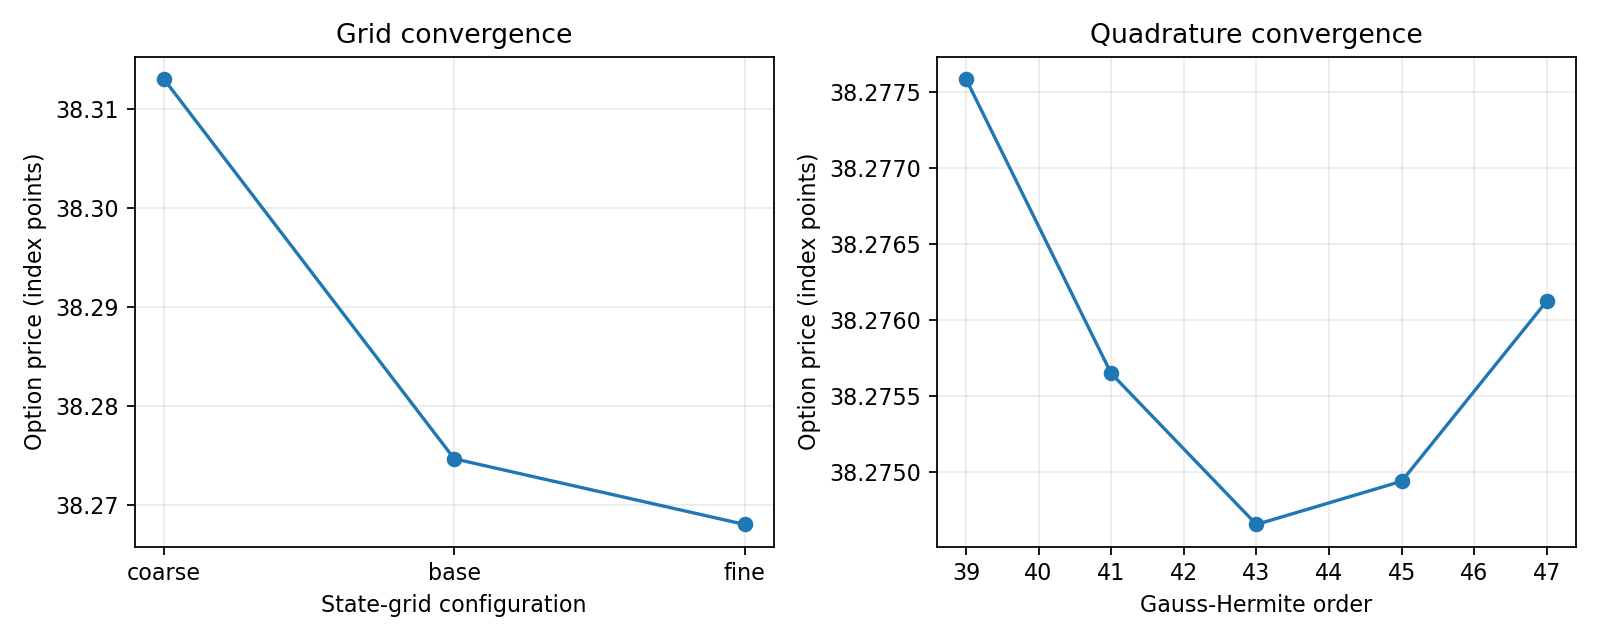

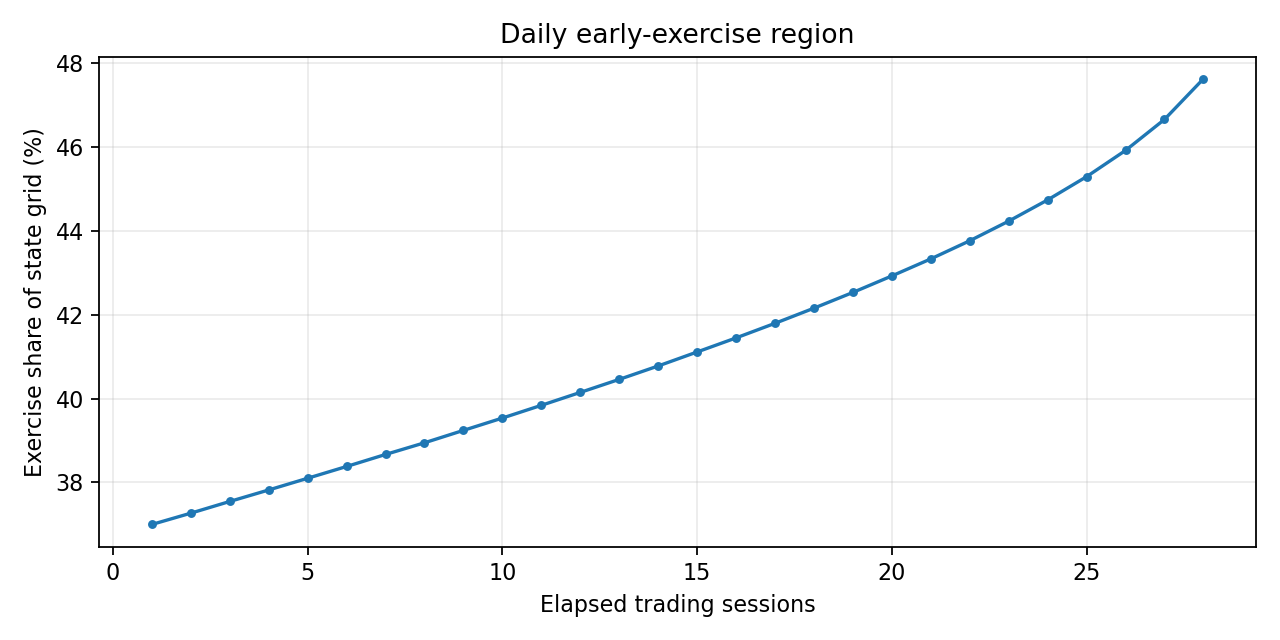

In [11]:
display(demo.pricing.grid_convergence)
display(demo.pricing.quadrature_convergence)
if OBSERVATION_NOISE_MODEL == 'constant_carry':
    display(Image(filename=str(DEMO_ROOT / 'outputs' / 'charts' / 'numerical_convergence.png')))
    display(Image(filename=str(DEMO_ROOT / 'outputs' / 'charts' / 'exercise_region.png')))
else:
    display(Image(filename=str(DEMO_ROOT / 'outputs_log_futures' / 'charts' / 'numerical_convergence.png')))
    display(Image(filename=str(DEMO_ROOT / 'outputs_log_futures' / 'charts' / 'exercise_region.png')))

The requested historical CSI 1000 volatility is estimated and passed into the pricing interface. Under the current zero-correlation assumptions, however, payoff homogeneity makes the option value proportional to spot and removes spot Brownian volatility from the normalized continuation problem. It will matter in an extension with spot/carry correlation or a non-homogeneous payoff.